In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen2.5-7B-Instruct",
    task = "conversational"
 )

model = ChatHuggingFace(llm = llm)

c:\Users\sushm\Desktop\Web development\Youtube\AI Engineering\LangGraph\newenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class LLMState(TypedDict):
    title: str
    outline:str
    detailed: str
    score: int

In [4]:
def promptChainningOutline(state:LLMState)->LLMState:
    title = state['title']
    prompt = f'Create a breif outline for a blog for the given topic {title}'
    result = model.invoke(prompt).content
    state['outline'] = result
    return state

In [5]:
def promptChainningDetailed(state:LLMState)->LLMState:
    title = state['title']
    outline = state['outline']
    prompt = f'Create a detailed blog for the given outline {outline} on topic {title}'
    result = model.invoke(prompt).content
    state['detailed'] = result
    return state

In [36]:
def promptChainningScore(state:LLMState)->LLMState:
    blog = state['detailed']
    scorePrompt = f'score the {blog} on a scale of 10 with no explaination needed for the given score. Do not explain your score or the blog just give a number of of 10'
    scoreResult = model.invoke(scorePrompt).content
    state['score'] = scoreResult
    return state

In [37]:
graph = StateGraph(LLMState)

graph.add_node('Define_outline',promptChainningOutline)
graph.add_node('Define_detailed',promptChainningDetailed)
graph.add_node('Score_Blog',promptChainningScore)

graph.add_edge(START,'Define_outline')
graph.add_edge('Define_outline','Define_detailed')
graph.add_edge('Define_detailed','Score_Blog')
graph.add_edge('Score_Blog',END)


workflow = graph.compile()

In [39]:
initial_state = {'title':"India and it's cricket"}
final_result = workflow.invoke(initial_state)
#print(final_result)
print(final_result['score'])

8


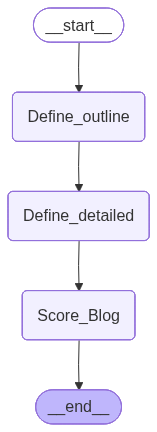

In [24]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())